# DOA Evaluation and Tracking

Evaluate an audio-only DOA checkpoint by sequence, apply circular tracking smoothing, and visualize raw versus tracked predictions.

In [1]:
%matplotlib inline

from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from dataloader.avped_audio_angle_dataloader import AVpedAudioAngleLoader
from dataloader.NeuralMusic_loader import AVPedNeuralMusicLoader
from network.audio_angle_net import AudioAngleNet
from network.NeuralMUSIC import NeuralMusic

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

In [5]:
# Configuration
DATA_ROOT = Path('data/pairs')
SPLIT = 'test'
CHECKPOINT = Path('output_audio_angle/model_best.pth')
NEURALMUSIC_CHECKPOINT = Path('output_neuralmusic/model_best.pth')
AUDIO_CHANNELS = (1,2,3,4)
FEATURE_TYPE = 'ipd'  # use 'mel' if the AudioAngleNet checkpoint was trained with mel features
NEURALMUSIC_FEATURE_TYPE = 'ipd'  # use 'magphase' for the older NeuralMUSIC input

# Match these to the values used during training.
DROPOUT_RATE = 0.4
FEATURE_DIM = 128
HIDDEN_DIM = 64
KERNEL_NUM = 8

BATCH_SIZE = 32
NUM_WORKERS = 4
EMA_ALPHA = 0.65  # online smoothing; larger = less delay
MEDIAN_WINDOW = 5  # offline zero-phase smoothing; odd number recommended
JUMP_GATE_DEG = 45.0  # only smooth small frame-to-frame changes
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

INPUT_CHANNELS = 1 + 2 * (len(AUDIO_CHANNELS) - 1) if FEATURE_TYPE == 'ipd' else len(AUDIO_CHANNELS)
print('device:', DEVICE)
NEURALMUSIC_INPUT_CHANNELS = 1 + 2 * (len(AUDIO_CHANNELS) - 1) if NEURALMUSIC_FEATURE_TYPE == 'ipd' else 2 * len(AUDIO_CHANNELS)
print('audio angle input channels:', INPUT_CHANNELS)
print('neuralmusic input channels:', NEURALMUSIC_INPUT_CHANNELS)

device: cuda:0
audio angle input channels: 7
neuralmusic input channels: 7


In [6]:
dataset = AVpedAudioAngleLoader(
    root_path=DATA_ROOT,
    split=SPLIT,
    audio_channels=AUDIO_CHANNELS,
    feature_type=FEATURE_TYPE,
    return_angle=True,
    return_metadata=True,
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = AudioAngleNet(
    dropout_rate=DROPOUT_RATE,
    feature_dim=FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    kernel_num=KERNEL_NUM,
    audio_channels=INPUT_CHANNELS,
).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

print('samples:', len(dataset))
print('audio angle checkpoint:', CHECKPOINT)

samples: 443
audio angle checkpoint: output_audio_angle/model_best.pth


In [7]:
def wrap_rad(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))


def angular_error_deg(pred_rad, gt_rad):
    return np.degrees(np.abs(wrap_rad(pred_rad - gt_rad)))


def circular_ema(angle_rad, alpha=0.65):
    tracked = np.empty_like(angle_rad)
    state = np.array([np.sin(angle_rad[0]), np.cos(angle_rad[0])], dtype=np.float64)
    tracked[0] = angle_rad[0]
    for i in range(1, len(angle_rad)):
        current = np.array([np.sin(angle_rad[i]), np.cos(angle_rad[i])], dtype=np.float64)
        state = (1.0 - alpha) * state + alpha * current
        state = state / np.linalg.norm(state)
        tracked[i] = np.arctan2(state[0], state[1])
    return tracked


def gated_circular_ema(angle_rad, alpha=0.65, jump_gate_deg=45.0):
    tracked = np.empty_like(angle_rad)
    state = angle_rad[0]
    tracked[0] = state
    gate = np.radians(jump_gate_deg)
    for i in range(1, len(angle_rad)):
        innovation = wrap_rad(angle_rad[i] - state)
        if abs(innovation) <= gate:
            state = wrap_rad(state + alpha * innovation)
        else:
            state = angle_rad[i]
        tracked[i] = state
    return tracked


def centered_circular_median(angle_rad, window=5):
    if window <= 1:
        return angle_rad.copy()
    radius = window // 2
    smoothed = np.empty_like(angle_rad)
    for i in range(len(angle_rad)):
        left = max(0, i - radius)
        right = min(len(angle_rad), i + radius + 1)
        local = angle_rad[left:right]
        center = np.arctan2(np.sin(local).mean(), np.cos(local).mean())
        local_unwrapped = center + wrap_rad(local - center)
        smoothed[i] = wrap_rad(np.median(local_unwrapped))
    return smoothed


def build_tracking_frame(records):
    table = pd.DataFrame(records).sort_values(['bag', 'stem']).reset_index(drop=True)
    table['gt_deg'] = np.degrees(table['gt_rad'])
    table['pred_deg'] = np.degrees(table['pred_rad'])
    table['raw_error_deg'] = angular_error_deg(table['pred_rad'].to_numpy(), table['gt_rad'].to_numpy())
    tracked_parts = []
    for bag, group in table.groupby('bag', sort=True):
        group = group.copy()
        pred = group['pred_rad'].to_numpy()
        group['ema_rad'] = circular_ema(pred, alpha=EMA_ALPHA)
        group['gated_rad'] = gated_circular_ema(pred, alpha=EMA_ALPHA, jump_gate_deg=JUMP_GATE_DEG)
        group['median_rad'] = centered_circular_median(pred, window=MEDIAN_WINDOW)
        tracked_parts.append(group)
    table = pd.concat(tracked_parts, ignore_index=True)
    for prefix in ['ema', 'gated', 'median']:
        table[f'{prefix}_deg'] = np.degrees(table[f'{prefix}_rad'])
        table[f'{prefix}_error_deg'] = angular_error_deg(table[f'{prefix}_rad'].to_numpy(), table['gt_rad'].to_numpy())
    return table


records = []
with torch.no_grad():
    for spec, _, gt_angle, meta in loader:
        pred_vec = model(spec.to(DEVICE)).cpu().numpy()
        pred_angle = np.arctan2(pred_vec[:, 0], pred_vec[:, 1])
        for i in range(len(pred_angle)):
            records.append({
                'bag': meta['bag'][i],
                'stem': meta['stem'][i],
                'gt_rad': float(gt_angle[i]),
                'pred_rad': float(pred_angle[i]),
            })

df = build_tracking_frame(records)

df.head()

,bag,stem,gt_rad,pred_rad,gt_deg,pred_deg,raw_error_deg,ema_rad,gated_rad,median_rad,ema_deg,ema_error_deg,gated_deg,gated_error_deg,median_deg,median_error_deg
0,rosbag2_2026_05_17-09_37_09,0001,-0.727393,-0.653648,-41.676547,-37.451269,4.225278,-0.653648,-0.653648,-0.759422,-37.451269,4.225278,-37.451269,4.225278,-43.511669,1.835122
1,rosbag2_2026_05_17-09_37_09,0002,-0.830591,-0.759422,-47.589384,-43.511669,4.077715,-0.722414,-0.722401,-0.837309,-41.391301,6.198083,-41.390529,6.198855,-47.974286,0.384902
2,rosbag2_2026_05_17-09_37_09,0003,-0.928536,-0.931009,-53.201218,-53.342903,0.141685,-0.858105,-0.857996,-0.905035,-49.165780,4.035438,-49.159572,4.041645,-51.854673,1.346544
3,rosbag2_2026_05_17-09_37_09,0004,-1.005650,-0.915197,-57.619496,-52.436902,5.182594,-0.895217,-0.895177,-0.915197,-51.292131,6.327365,-51.289837,6.329659,-52.436902,5.182594
4,rosbag2_2026_05_17-09_37_09,0005,-1.116075,-0.905035,-63.946369,-51.854673,12.091696,-0.901598,-0.901584,-0.931009,-51.657784,12.288585,-51.656981,12.289388,-53.342903,10.603466


In [8]:
def summarize(table):
    summary = (
        table.groupby('bag')
        .agg(
            frames=('stem', 'count'),
            raw_mae_deg=('raw_error_deg', 'mean'),
            ema_mae_deg=('ema_error_deg', 'mean'),
            gated_mae_deg=('gated_error_deg', 'mean'),
            median_mae_deg=('median_error_deg', 'mean'),
            raw_median_deg=('raw_error_deg', 'median'),
            ema_median_deg=('ema_error_deg', 'median'),
            gated_median_deg=('gated_error_deg', 'median'),
            median_filter_median_deg=('median_error_deg', 'median'),
        )
        .sort_index()
    )
    summary.loc['ALL'] = {
        'frames': len(table),
        'raw_mae_deg': table['raw_error_deg'].mean(),
        'ema_mae_deg': table['ema_error_deg'].mean(),
        'gated_mae_deg': table['gated_error_deg'].mean(),
        'median_mae_deg': table['median_error_deg'].mean(),
        'raw_median_deg': table['raw_error_deg'].median(),
        'ema_median_deg': table['ema_error_deg'].median(),
        'gated_median_deg': table['gated_error_deg'].median(),
        'median_filter_median_deg': table['median_error_deg'].median(),
    }
    return summary


summary = summarize(df)
summary.round(3)

,frames,raw_mae_deg,ema_mae_deg,gated_mae_deg,median_mae_deg,raw_median_deg,ema_median_deg,gated_median_deg,median_filter_median_deg
bag,,,,,,,,,
rosbag2_2026_05_17-09_37_09,131,8.732,7.890,8.393,5.477,5.250,5.753,6.158,5.036
rosbag2_2026_05_17-09_40_57,128,8.610,7.400,7.665,5.895,6.093,6.490,5.810,4.958
rosbag2_2026_05_17-09_43_22,98,6.960,6.458,6.462,6.121,5.728,4.973,4.966,5.078
rosbag2_2026_05_17-09_44_16,86,6.638,6.862,7.244,5.291,5.294,5.279,5.457,4.768
ALL,443,7.898,7.232,7.532,5.704,5.617,5.537,5.613,5.002


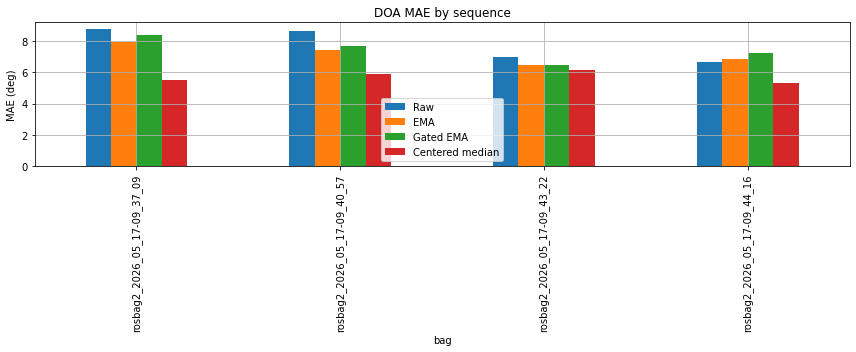

In [9]:
ax = summary.drop(index='ALL').plot.bar(y=['raw_mae_deg', 'ema_mae_deg', 'gated_mae_deg', 'median_mae_deg'], figsize=(12, 5))
ax.set_ylabel('MAE (deg)')
ax.set_title('DOA MAE by sequence')
ax.legend(['Raw', 'EMA', 'Gated EMA', 'Centered median'])
plt.tight_layout()
plt.show()

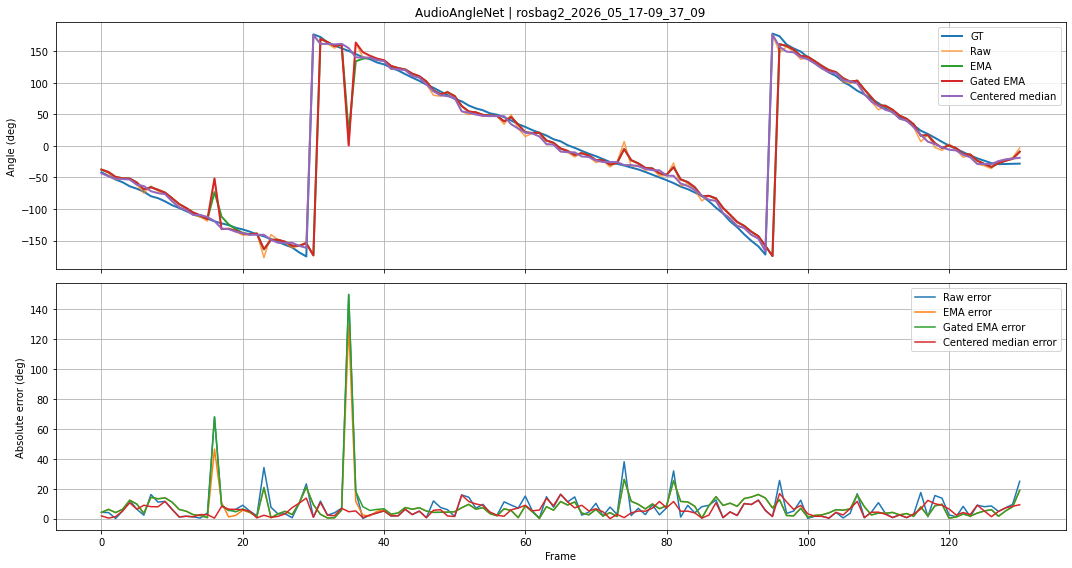

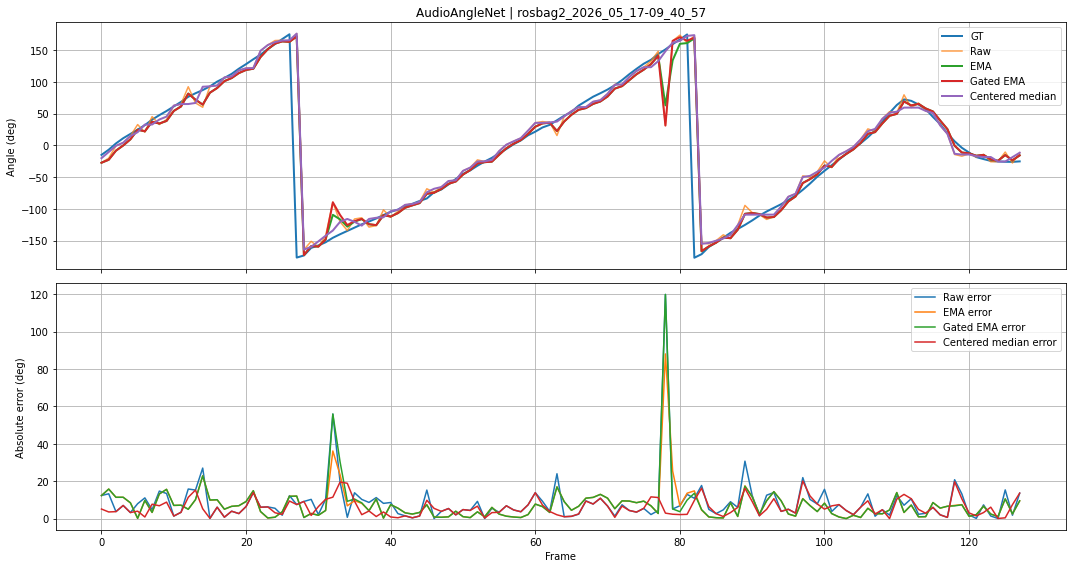

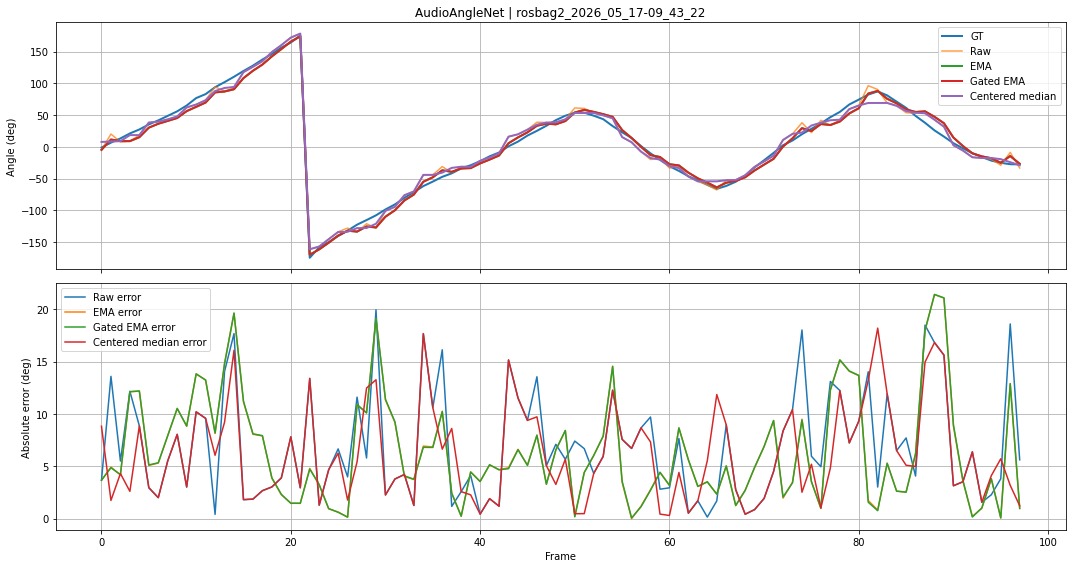

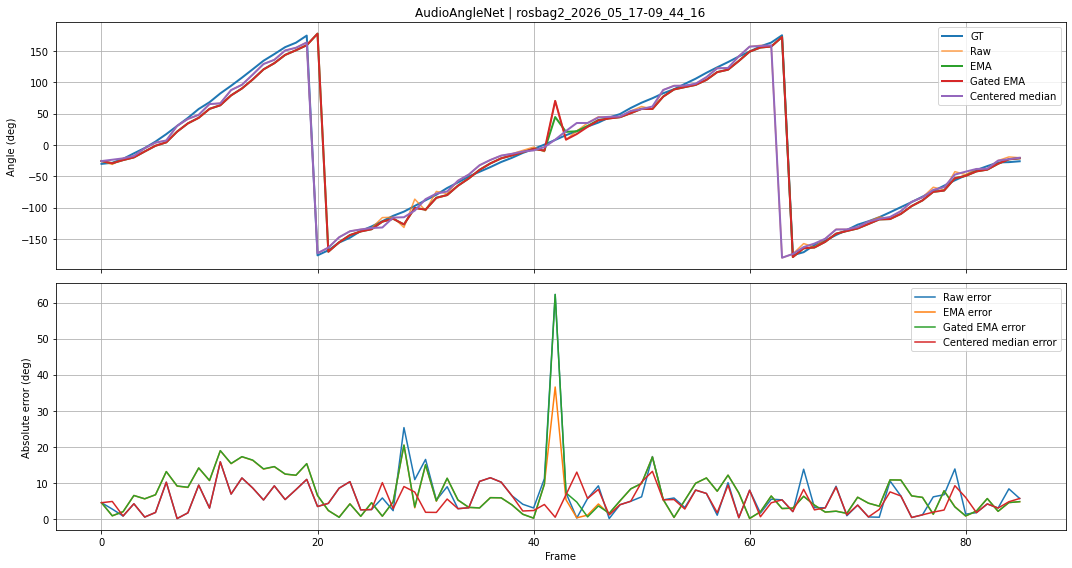

In [10]:
def plot_sequence(bag, table=df, title_prefix='AudioAngleNet'):
    seq = table[table['bag'] == bag].reset_index(drop=True)
    x = np.arange(len(seq))
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    axes[0].plot(x, seq['gt_deg'], label='GT', linewidth=2)
    axes[0].plot(x, seq['pred_deg'], label='Raw', alpha=0.75)
    axes[0].plot(x, seq['ema_deg'], label='EMA', linewidth=2)
    axes[0].plot(x, seq['gated_deg'], label='Gated EMA', linewidth=2)
    axes[0].plot(x, seq['median_deg'], label='Centered median', linewidth=2)
    axes[0].set_ylabel('Angle (deg)')
    axes[0].set_title(f'{title_prefix} | {bag}')
    axes[0].legend()

    axes[1].plot(x, seq['raw_error_deg'], label='Raw error')
    axes[1].plot(x, seq['ema_error_deg'], label='EMA error')
    axes[1].plot(x, seq['gated_error_deg'], label='Gated EMA error')
    axes[1].plot(x, seq['median_error_deg'], label='Centered median error')
    axes[1].set_xlabel('Frame')
    axes[1].set_ylabel('Absolute error (deg)')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


for bag in sorted(df['bag'].unique()):
    plot_sequence(bag)

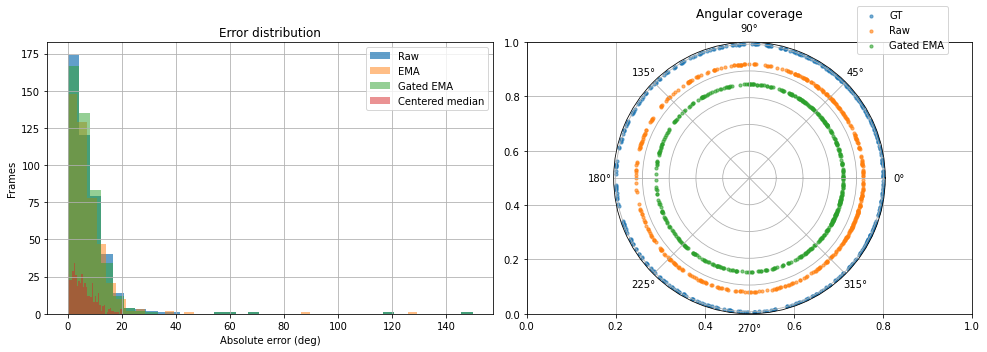

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['raw_error_deg'], bins=36, alpha=0.7, label='Raw')
axes[0].hist(df['ema_error_deg'], bins=36, alpha=0.5, label='EMA')
axes[0].hist(df['gated_error_deg'], bins=36, alpha=0.5, label='Gated EMA')
axes[0].hist(df['median_error_deg'], bins=36, alpha=0.5, label='Centered median')
axes[0].set_xlabel('Absolute error (deg)')
axes[0].set_ylabel('Frames')
axes[0].set_title('Error distribution')
axes[0].legend()

axes[1] = plt.subplot(1, 2, 2, projection='polar')
sampled = df.iloc[::max(len(df) // 300, 1)]
axes[1].scatter(sampled['gt_rad'], np.ones(len(sampled)), s=10, alpha=0.6, label='GT')
axes[1].scatter(sampled['pred_rad'], np.ones(len(sampled)) * 0.85, s=10, alpha=0.6, label='Raw')
axes[1].scatter(sampled['gated_rad'], np.ones(len(sampled)) * 0.7, s=10, alpha=0.6, label='Gated EMA')
axes[1].set_yticklabels([])
axes[1].set_title('Angular coverage')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))
plt.tight_layout()
plt.show()

## NeuralMUSIC evaluation

Run the same sequence-level analysis for a NeuralMUSIC checkpoint.


In [12]:
nm_dataset = AVPedNeuralMusicLoader(
    root_path=DATA_ROOT,
    split=SPLIT,
    audio_channels=AUDIO_CHANNELS,
    feature_type=NEURALMUSIC_FEATURE_TYPE,
    geometry_aug=False,
)
nm_loader = DataLoader(nm_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

nm_model = NeuralMusic(
    N=len(AUDIO_CHANNELS),
    T=8000,
    M=1,
    device=DEVICE,
    input_channel=NEURALMUSIC_INPUT_CHANNELS,
).to(DEVICE)
nm_model.load_state_dict(torch.load(NEURALMUSIC_CHECKPOINT, map_location=DEVICE))
nm_model.eval()

print('neuralmusic samples:', len(nm_dataset))
print('neuralmusic checkpoint:', NEURALMUSIC_CHECKPOINT)


neuralmusic samples: 443
neuralmusic checkpoint: output_neuralmusic/model_best.pth


In [14]:
nm_records = []
with torch.no_grad():
    offset = 0
    for spec, gt_deg, sv, corr in nm_loader:
        _, spectrum = nm_model(spec.to(DEVICE), sv.to(DEVICE), corr.to(DEVICE))
        pred_deg = torch.argmax(spectrum, dim=1).cpu().numpy().astype(np.float32)
        batch_size = len(pred_deg)
        batch_samples = nm_dataset.samples[offset:offset + batch_size]
        for i, sample in enumerate(batch_samples):
            nm_records.append({
                'bag': sample['bag'],
                'stem': sample['stem'],
                'gt_rad': np.deg2rad(float(gt_deg[i, 0])),
                'pred_rad': np.deg2rad(float(pred_deg[i])),
            })
        offset += batch_size

nm_df = build_tracking_frame(nm_records)
nm_summary = summarize(nm_df)
nm_summary.round(3)


,frames,raw_mae_deg,ema_mae_deg,gated_mae_deg,median_mae_deg,raw_median_deg,ema_median_deg,gated_median_deg,median_filter_median_deg
bag,,,,,,,,,
rosbag2_2026_05_17-09_37_09,131,8.024,7.045,7.480,4.220,4.176,4.542,4.450,3.549
rosbag2_2026_05_17-09_40_57,128,7.453,7.515,7.437,5.221,5.313,5.588,5.630,4.518
rosbag2_2026_05_17-09_43_22,98,6.672,6.024,6.234,5.823,6.032,5.228,5.246,5.011
rosbag2_2026_05_17-09_44_16,86,6.445,6.225,6.240,5.300,4.875,4.772,4.785,4.277
ALL,443,7.253,6.796,6.951,5.073,4.933,5.200,5.177,4.274


In [15]:
compare = pd.DataFrame({
    'AudioAngleNet raw': summary['raw_mae_deg'],
    'NeuralMUSIC raw': nm_summary['raw_mae_deg'],
    'AudioAngleNet gated': summary['gated_mae_deg'],
    'NeuralMUSIC gated': nm_summary['gated_mae_deg'],
})
compare.round(3)


,AudioAngleNet raw,NeuralMUSIC raw,AudioAngleNet gated,NeuralMUSIC gated
bag,,,,
rosbag2_2026_05_17-09_37_09,8.732,8.024,8.393,7.480
rosbag2_2026_05_17-09_40_57,8.610,7.453,7.665,7.437
rosbag2_2026_05_17-09_43_22,6.960,6.672,6.462,6.234
rosbag2_2026_05_17-09_44_16,6.638,6.445,7.244,6.240
ALL,7.898,7.253,7.532,6.951


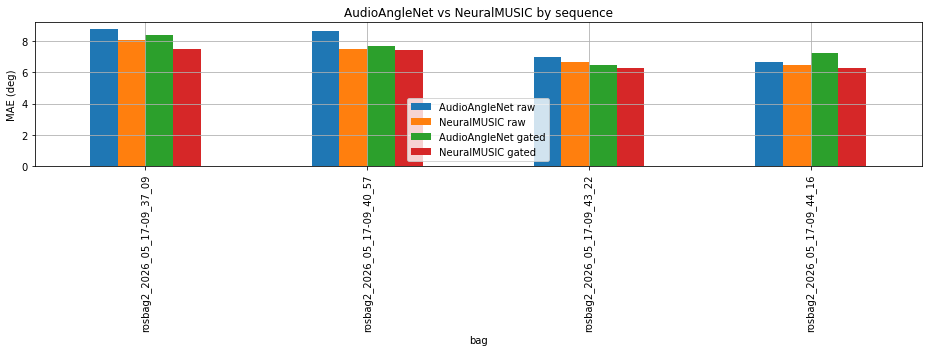

In [16]:
ax = compare.drop(index='ALL').plot.bar(figsize=(13, 5))
ax.set_ylabel('MAE (deg)')
ax.set_title('AudioAngleNet vs NeuralMUSIC by sequence')
plt.tight_layout()
plt.show()


## LiDAR overlays

Use bird's-eye-view point clouds to inspect where each DOA estimate points in the scene.

In [17]:
from matplotlib.patches import Polygon


def load_lidar_points(bag, stem):
    path = DATA_ROOT / SPLIT / bag / 'lidar' / f'{stem}.bin'
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)


def load_bbox(bag, stem):
    path = DATA_ROOT / SPLIT / bag / 'labels' / f'{stem}.txt'
    parts = path.read_text().strip().split()
    h, w, l = map(float, parts[8:11])
    x, y, z, yaw = map(float, parts[11:15])
    return np.asarray([x, y, z, l, w, h, yaw], dtype=np.float32)


def bbox_bev_corners(box):
    x, y, _, dx, dy, _, yaw = box
    corners = np.asarray([[dx / 2, dy / 2], [dx / 2, -dy / 2], [-dx / 2, -dy / 2], [-dx / 2, dy / 2]], dtype=np.float32)
    rotation = np.asarray([[np.cos(yaw), -np.sin(yaw)], [np.sin(yaw), np.cos(yaw)]], dtype=np.float32)
    return corners @ rotation.T + np.asarray([x, y], dtype=np.float32)


def ray_xy(angle_rad, radius=4.0):
    return np.asarray([[0.0, 0.0], [radius * np.cos(angle_rad), radius * np.sin(angle_rad)]])


def plot_lidar_frame(row, ax=None, radius=4.0, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    points = load_lidar_points(row['bag'], row['stem'])
    box = load_bbox(row['bag'], row['stem'])
    scatter = ax.scatter(points[:, 0], points[:, 1], c=points[:, 2], s=0.4, cmap='viridis', alpha=0.8)
    ax.add_patch(Polygon(bbox_bev_corners(box), closed=True, fill=False, edgecolor='red', linewidth=2, label='GT bbox'))
    for label, angle, color in [
        ('GT DOA', row['gt_rad'], 'red'),
        ('Raw', row['pred_rad'], 'orange'),
        ('Gated EMA', row['gated_rad'], 'cyan'),
        ('Centered median', row['median_rad'], 'magenta'),
    ]:
        ray = ray_xy(angle, radius=radius)
        ax.plot(ray[:, 0], ray[:, 1], color=color, linewidth=2, label=label)
    ax.scatter([0], [0], c='white', edgecolors='black', s=45, zorder=5)
    ax.set_xlim(-radius - 0.2, radius + 0.2)
    ax.set_ylim(-radius - 0.2, radius + 0.2)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title or f"{row['bag']} / {row['stem']}\nraw={row['raw_error_deg']:.1f} deg, gated={row['gated_error_deg']:.1f} deg")
    return scatter

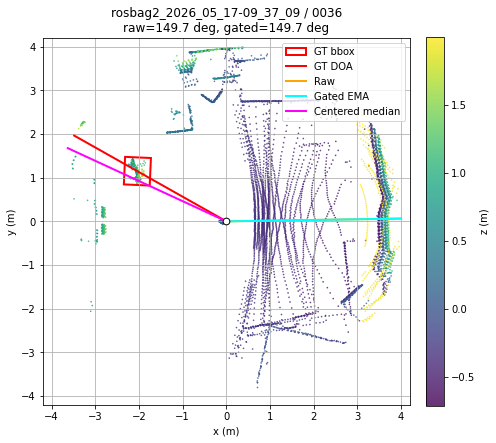

In [18]:
# Single-frame example: the largest raw DOA error in the current split
example_row = df.sort_values('raw_error_deg', ascending=False).iloc[0]
fig, ax = plt.subplots(figsize=(7, 7))
scatter = plot_lidar_frame(example_row, ax=ax)
ax.legend(loc='upper right')
fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, label='z (m)')
plt.tight_layout()
plt.show()

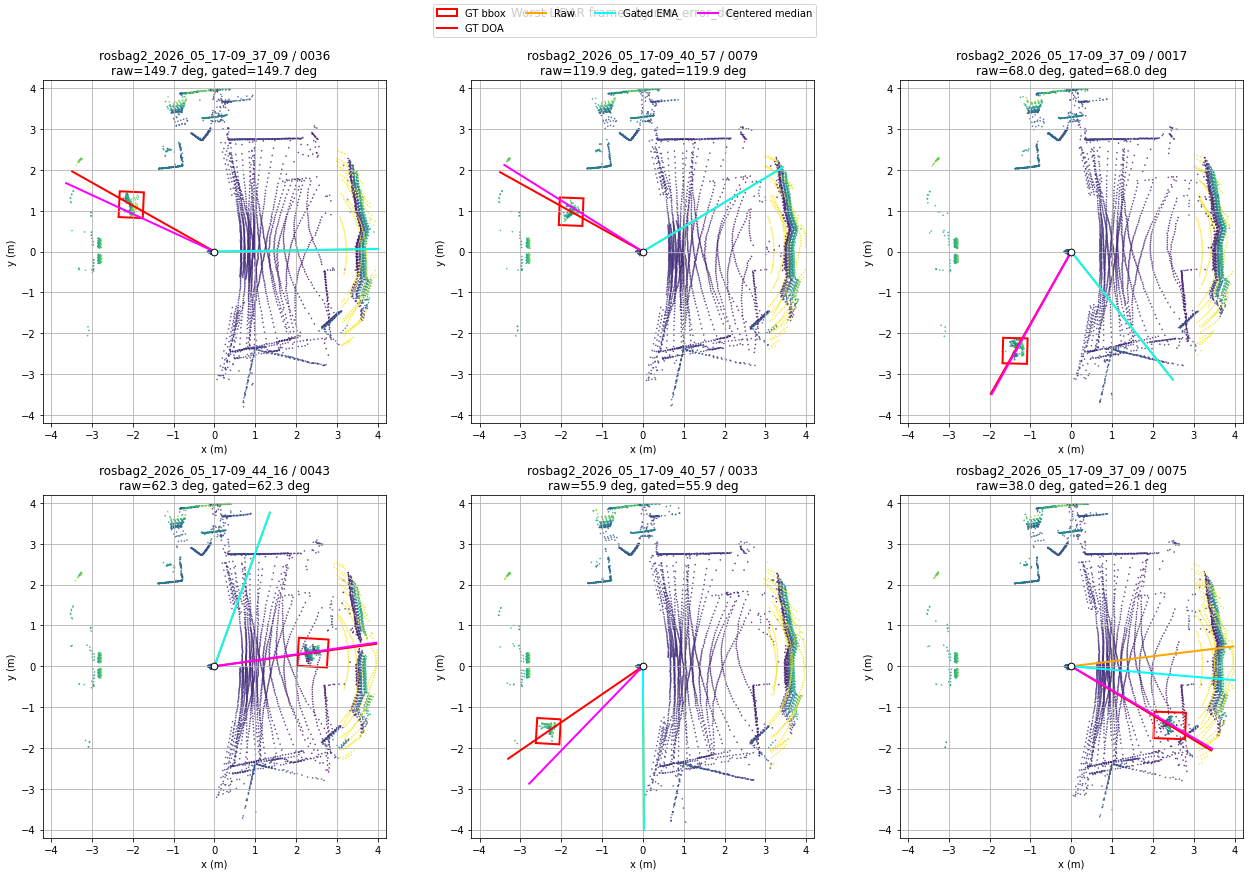

In [19]:
def plot_worst_lidar_frames(table=df, bag=None, top_k=6, sort_by='raw_error_deg'):
    subset = table if bag is None else table[table['bag'] == bag]
    rows = subset.sort_values(sort_by, ascending=False).head(top_k)
    cols = min(3, top_k)
    rows_n = int(np.ceil(top_k / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(6 * cols, 6 * rows_n))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, rows.iterrows()):
        plot_lidar_frame(row, ax=ax)
    for ax in axes[len(rows):]:
        ax.axis('off')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)
    fig.suptitle(f"Worst LiDAR frames by {sort_by}" + (f" | {bag}" if bag else ''), y=1.01)
    plt.tight_layout()
    plt.show()


plot_worst_lidar_frames(top_k=6)


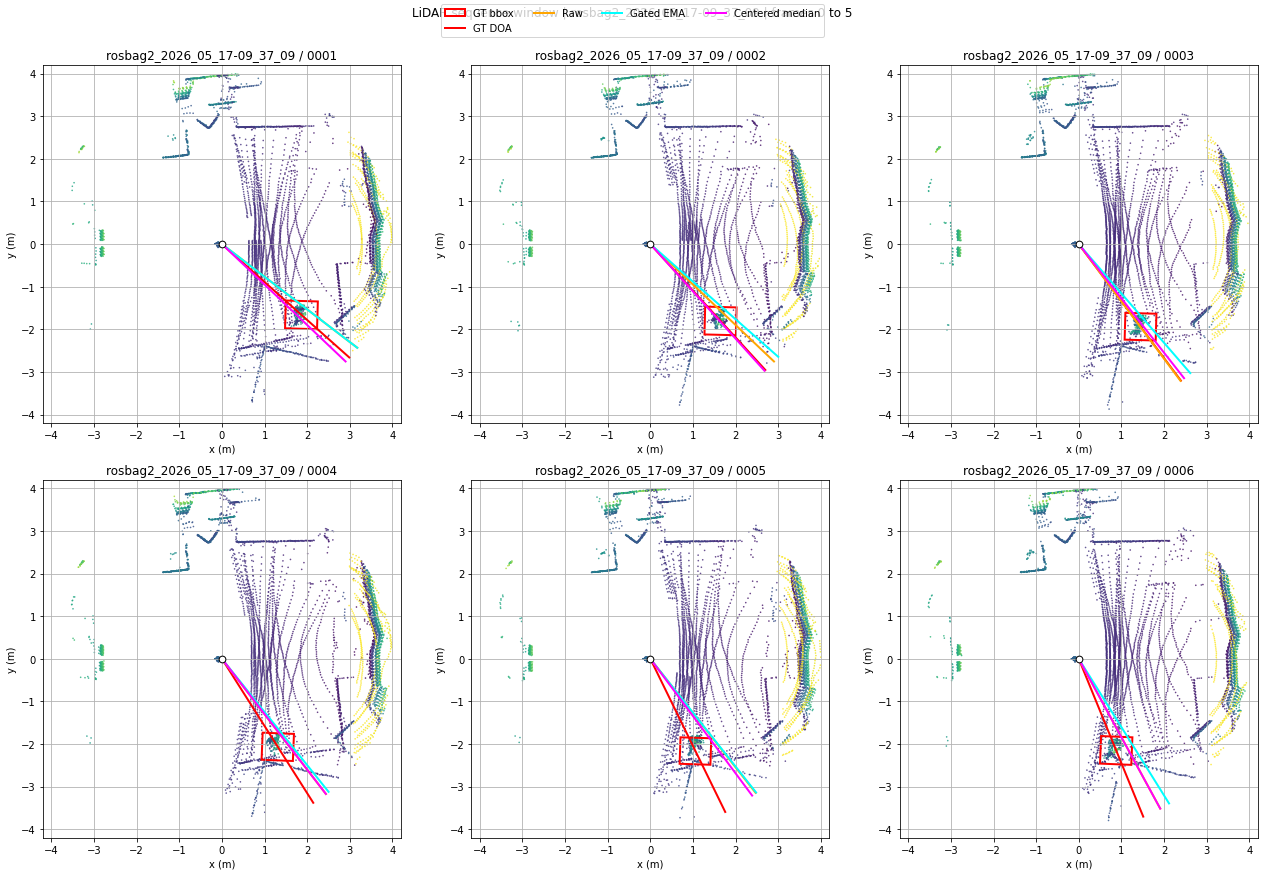

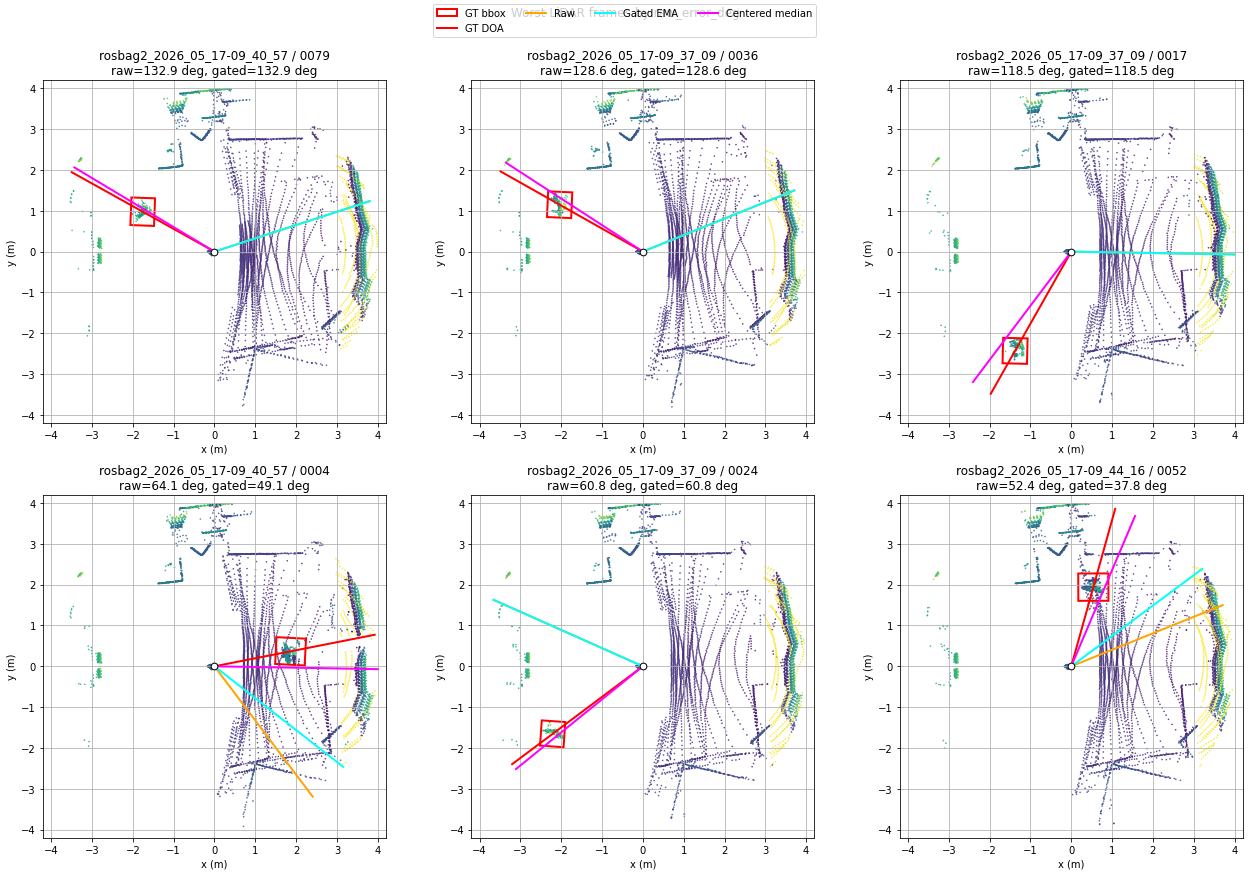

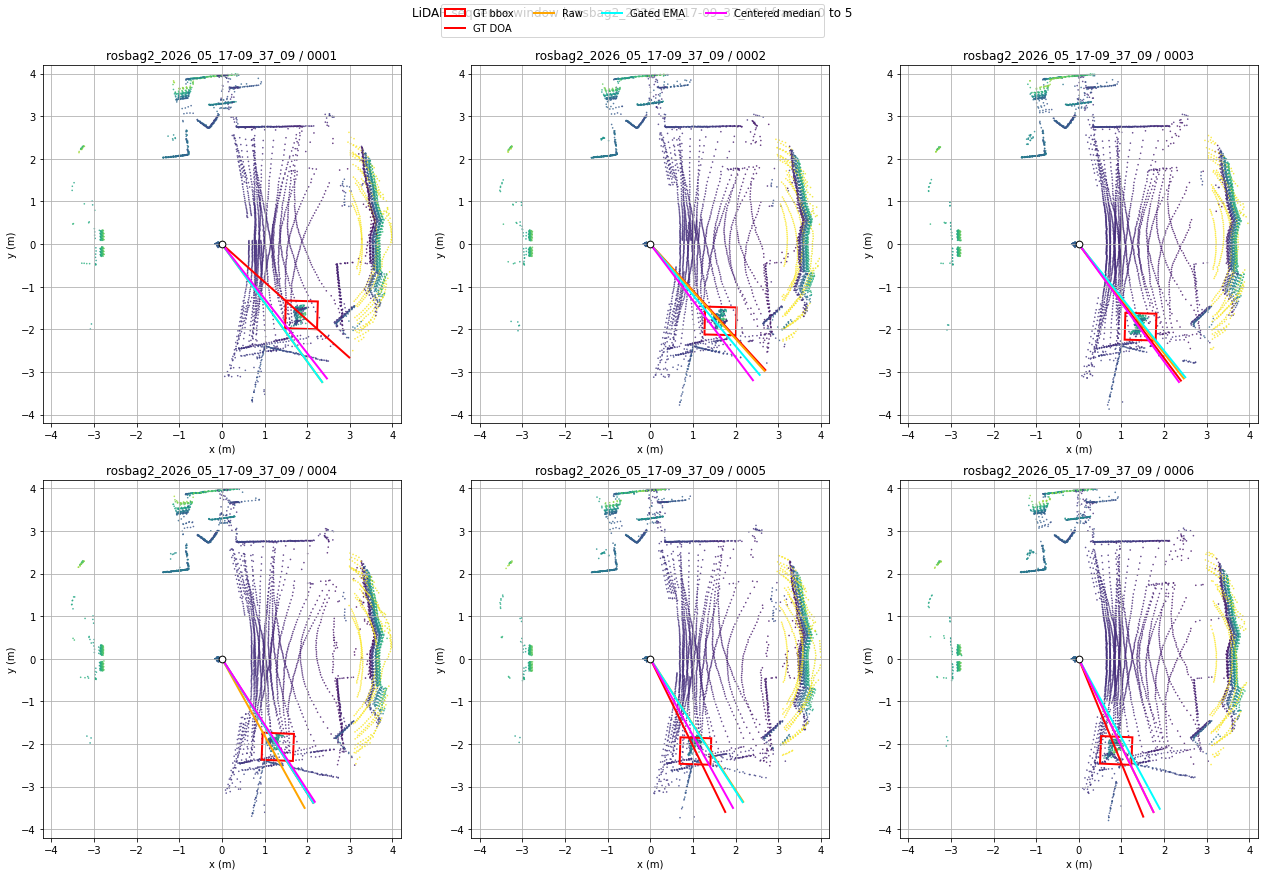

In [20]:
def plot_lidar_sequence_window(bag, table=df, start=0, count=6):
    seq = table[table['bag'] == bag].reset_index(drop=True)
    rows = seq.iloc[start:start + count]
    cols = min(3, len(rows))
    rows_n = int(np.ceil(len(rows) / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(6 * cols, 6 * rows_n))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, rows.iterrows()):
        plot_lidar_frame(row, ax=ax, title=f"{bag} / {row['stem']}")
    for ax in axes[len(rows):]:
        ax.axis('off')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)
    fig.suptitle(f"LiDAR sequence window | {bag} | frames {start} to {start + len(rows) - 1}", y=1.01)
    plt.tight_layout()
    plt.show()


first_bag = sorted(df['bag'].unique())[0]
plot_lidar_sequence_window(first_bag, start=0, count=6)
# NeuralMUSIC LiDAR examples
plot_worst_lidar_frames(table=nm_df, top_k=6)
plot_lidar_sequence_window(first_bag, table=nm_df, start=0, count=6)
